In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
pd.set_option('display.max_columns', None)

# 1. Import data

In [ ]:
path_to_test = r"data\customer_clv_test.csv"
path_to_train = r"data\customer_clv_train.csv"
path_to_transactions = r"data\transactions_2016_2017.csv"

In [4]:
train = pd.read_csv(path_to_train)
test = pd.read_csv(path_to_test)
transactions = pd.read_csv(path_to_transactions)

print("Dimensions: train:", train.shape, " test:", test.shape, 'transactions:', transactions.shape)
print("Train columns:", train.columns.to_list())
print("Transaction columns:", transactions.columns.to_list())

C:\Users\Marte\AppData\Local\Temp\ipykernel_24272\3911849424.py:3: DtypeWarning: Columns (0: prod_size) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv(path_to_transactions)


Dimensions: train: (116591, 2)  test: (29148, 1) transactions: (344212, 26)
Train columns: ['cust_id', 'revenue_2018_2019']
Transaction columns: ['cust_id', 'order_date', 'pack_date', 'sale_id', 'sale_discount_applied', 'sale_revenue', 'returned_to_shop_id', 'prod_id', 'prod_size', 'prod_web_only', 'prod_season', 'prod_brand', 'prod_title', 'prod_color', 'prod_type_1', 'prod_type_3', 'prod_type_4', 'prod_type_5', 'prod_heel', 'prod_material', 'prod_insole', 'prod_print', 'prod_comfort_sole', 'prod_comfort_wear', 'prod_clasp', 'prod_outlet']


In [34]:
print(train.head())
print(test.head())
print(transactions.head())

            cust_id  revenue_2018_2019
0  klantwj2374mzmab             209.85
1  a63atwr2ig2jfprr              82.93
2  zr7ihbfbi6gcy2tz              89.95
3  dt7cthjqnjmkbiu6               0.00
4  etcrrgcbrzfovyzj               0.00
            cust_id
0  2dfoualegmpt6x2h
1  d2q2stjpnzld7a4r
2  cojscuqlpylhclv2
3  vntezlhi2ryvxk6m
4  jgy4ytjkdr2b75wf
            cust_id  order_date   pack_date           sale_id  \
0  klantwj2374mzmab  2016-01-01  2016-01-04  wa46phiwo6neterg   
1  klantwj2374mzmab  2016-01-01  2016-01-04  wa46phiwo6neterg   
2  a63atwr2ig2jfprr  2016-01-01  2016-01-04  p4y4726y24dcxawf   
3  zr7ihbfbi6gcy2tz  2016-01-01  2016-01-05  3etkl2xv6pxku4kt   
4  dt7cthjqnjmkbiu6  2016-01-01  2016-01-05  lneitdgyfvrie3jo   

   sale_discount_applied  sale_revenue returned_to_shop_id           prod_id  \
0                 -35.70         83.30                 NaN  543rj4mzzjnzkbil   
1                 -39.98          0.00          ztodvuuaje  7ewnqhtrquent4cy   
2              

In [35]:
transactions["order_date"] = pd.to_datetime(transactions["order_date"], errors='coerce')
transactions['pack_date'] = pd.to_datetime(transactions["pack_date"], errors='coerce')

print("missing values in order_date:", transactions["order_date"].isna().sum())
print("missing values in pack_date:", transactions['pack_date'].isna().sum())

missing values in order_date: 0
missing values in pack_date: 0


# 2. Target Variable

rows : 116591 | percent of O: 63.41
count    116591.000000
mean         70.364667
std         144.303602
min           0.000000
50%           0.000000
90%         229.940000
95%         363.465000
99%         704.242000
max        1197.940000
Name: revenue_2018_2019, dtype: float64


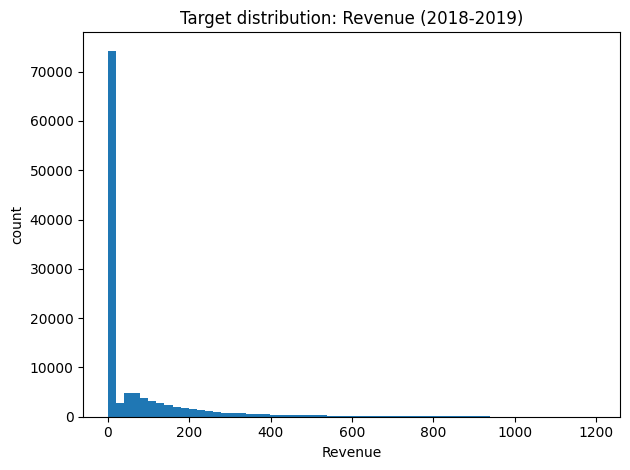

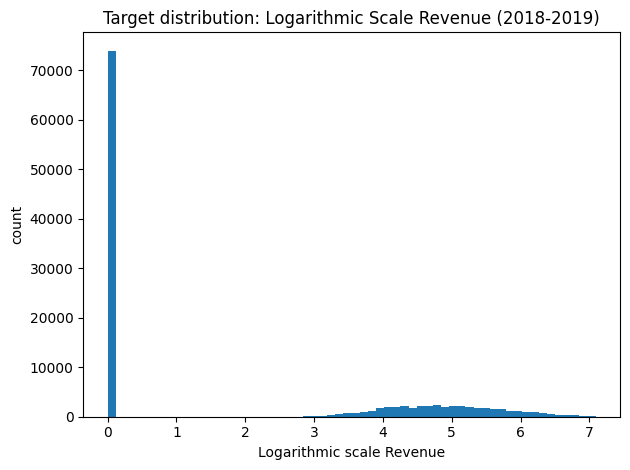

In [28]:
TARGET_VAR = "revenue_2018_2019"

y = pd.to_numeric(train[TARGET_VAR].dropna())
print('rows :', len(y), "| percent of O:", round(y.eq(0).mean() * 100,2))
print(y.describe(percentiles=[.5,.9,.95,.99]))

plt.figure()
plt.hist(y, bins=60)
plt.title(f"Target distribution: Revenue (2018-2019)")
plt.xlabel("Revenue"); plt.ylabel("count")
plt.tight_layout(); plt.show()

plt.figure()
plt.hist(np.log1p(y), bins=60)
plt.title(f"Target distribution: Logarithmic Scale Revenue (2018-2019)")
plt.xlabel(f"Logarithmic scale Revenue"); plt.ylabel("count")
plt.tight_layout(); plt.show()



In [11]:
print(np.log1p(y).describe(percentiles=[.5,.9,.95,.99]))

count    116591.000000
mean          1.793202
std           2.416395
min           0.000000
50%           0.000000
90%           5.442158
95%           5.898431
99%           6.558541
max           7.089193
Name: revenue_2018_2019, dtype: float64


# 3. Data Exploration

In [ ]:
transactions.info()
transactions.head()

<class 'pandas.DataFrame'>
RangeIndex: 344212 entries, 0 to 344211
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   cust_id                344212 non-null  str           
 1   order_date             344212 non-null  datetime64[us]
 2   pack_date              344212 non-null  datetime64[us]
 3   sale_id                344212 non-null  str           
 4   sale_discount_applied  344212 non-null  float64       
 5   sale_revenue           344212 non-null  float64       
 6   returned_to_shop_id    63930 non-null   str           
 7   prod_id                344212 non-null  str           
 8   prod_size              344212 non-null  object        
 9   prod_web_only          344212 non-null  int64         
 10  prod_season            344212 non-null  str           
 11  prod_brand             344212 non-null  str           
 12  prod_title             344212 non-null  str           


In [5]:
# Ordinal/metric variables
print(transactions['sale_revenue'].describe())
print(transactions['sale_discount_applied'].describe())
print(pd.to_numeric(transactions['prod_size'], errors='coerce').describe())
print(transactions['order_date'].describe())
print(transactions['pack_date'].describe())

count    344212.000000
mean         53.074974
std          38.108857
min        -200.000000
25%          27.000000
50%          53.000000
75%          75.950000
max         275.000000
Name: sale_revenue, dtype: float64
count    344212.000000
mean        -20.646063
std          22.479681
min        -200.000000
25%         -31.500000
50%         -12.000000
75%          -4.590000
max           1.000000
Name: sale_discount_applied, dtype: float64
count    344211.000000
mean         36.873986
std           5.764064
min          16.000000
25%          35.000000
50%          38.000000
75%          40.000000
max          50.000000
Name: prod_size, dtype: float64
count         344212
unique           731
top       2017-07-31
freq            4264
Name: order_date, dtype: object
count         344212
unique           538
top       2017-07-31
freq            3156
Name: pack_date, dtype: object


In [ ]:
# List unique values for nominal variables
nominal_cols = ['cust_id', 'sale_id', 'prod_title', 'returned_to_shop_id','prod_id', 'prod_brand', 'prod_color', 'prod_type_1', 'prod_type_3', 'prod_material', 'sale_id', 'prod_size', 'prod_season', 'prod_title', 'prod_type_4', 'prod_type_5', 'prod_heel', 'prod_insole', 'prod_print', 'prod_comfort_sole', 'prod_comfort_wear', 'prod_clasp', 'prod_outlet']

print(f"{'Variable':<20} | {'Unique values':<15}")
print("-" * 40)
for col in nominal_cols:
    count = transactions[col].nunique()
    print(f"{col:<20} | {count:<15}")

Variabele            | Unieke Waarden 
----------------------------------------
cust_id              | 145739         
sale_id              | 245928         
prod_title           | 21302          
returned_to_shop_id  | 78             
prod_id              | 22324          
prod_brand           | 493            
prod_color           | 41             
prod_type_1          | 4              
prod_type_3          | 41             
prod_material        | 58             
sale_id              | 245928         
prod_size            | 129            
prod_season          | 23             
prod_title           | 21302          
prod_type_4          | 48             
prod_type_5          | 51             
prod_heel            | 4              
prod_insole          | 2              
prod_print           | 128            
prod_comfort_sole    | 51             
prod_comfort_wear    | 13             
prod_clasp           | 48             
prod_outlet          | 2              


In [7]:
for column in transactions.columns.tolist():
    print("Missing values in", column, 'is', transactions[column].isna().sum(), " and percentage of the column missing", round(transactions[column].isna().mean() * 100, 2))

Missing values in cust_id is 0  and percentage of the column missing 0.0
Missing values in order_date is 0  and percentage of the column missing 0.0
Missing values in pack_date is 0  and percentage of the column missing 0.0
Missing values in sale_id is 0  and percentage of the column missing 0.0
Missing values in sale_discount_applied is 0  and percentage of the column missing 0.0
Missing values in sale_revenue is 0  and percentage of the column missing 0.0
Missing values in returned_to_shop_id is 280282  and percentage of the column missing 81.43
Missing values in prod_id is 0  and percentage of the column missing 0.0
Missing values in prod_size is 0  and percentage of the column missing 0.0
Missing values in prod_web_only is 0  and percentage of the column missing 0.0
Missing values in prod_season is 0  and percentage of the column missing 0.0
Missing values in prod_brand is 0  and percentage of the column missing 0.0
Missing values in prod_title is 0  and percentage of the column mi

In [8]:
for column in transactions.columns.to_list():
    print('Descriptive statistics for', column, ':', transactions[column].describe())

Descriptive statistics for cust_id : count               344212
unique              145739
top       yvmh4jb3ltqygxnt
freq                   142
Name: cust_id, dtype: object
Descriptive statistics for order_date : count         344212
unique           731
top       2017-07-31
freq            4264
Name: order_date, dtype: object
Descriptive statistics for pack_date : count         344212
unique           538
top       2017-07-31
freq            3156
Name: pack_date, dtype: object
Descriptive statistics for sale_id : count               344212
unique              245928
top       lwvlicnwtljqoq7z
freq                    28
Name: sale_id, dtype: object
Descriptive statistics for sale_discount_applied : count    344212.000000
mean        -20.646063
std          22.479681
min        -200.000000
25%         -31.500000
50%         -12.000000
75%          -4.590000
max           1.000000
Name: sale_discount_applied, dtype: float64
Descriptive statistics for sale_revenue : count    344212.00000

# 4. Data Cleaning

In [9]:
print(len(transactions['prod_brand'].unique()))

493


In [10]:
for column in ["prod_clasp","prod_comfort_wear","prod_comfort_sole","prod_print","prod_insole","prod_heel","prod_type_4"]:
    transactions.drop(column, axis=1, inplace=True)

In [11]:
## for returned_to_shop_id , prod_type_5 , prod_material NANs ???
for column in ["prod_type_5","prod_material","returned_to_shop_id"]:
    transactions[column].fillna('missing', inplace=True)

## still relevant to keep this feature with so many NaNs ??

C:\Users\Marte\AppData\Local\Temp\ipykernel_24272\1170069323.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  transactions[column].fillna('missing', inplace=True)


In [12]:
## duplicates
count= transactions.duplicated().sum()
percentage= round(count/len(transactions)*100,2)
print("Duplicated rows:",count, "percentage:", percentage )
## <1% so no problem

Duplicated rows: 1063 percentage: 0.31


In [13]:
for column in ["prod_season","prod_color","prod_type_1","prod_type_3","prod_type_5","prod_material"]:
    print("Unique for" ,column, sorted(transactions[column].unique()))

Unique for prod_season ['CONS', 'MW14', 'MW17', 'MZ15', 'MZ16', 'MZ17', 'NOS', 'SW17', 'SZ17', 'SZ18', 'W12', 'W13', 'W14', 'W15', 'W16', 'W17', 'W18', 'Z13', 'Z14', 'Z15', 'Z16', 'Z17', 'Z18']
Unique for prod_color ['aubergine', 'black', 'blue', 'bronze', 'brown', 'burgundy', 'camouflage', 'cognac', 'dark beige', 'dark blue', 'dark brown', 'dark green', 'dark grey', 'dark red', 'dark yellow', 'ecru', 'fuchsia', 'gold', 'green', 'grey', 'khaki', 'light beige', 'light blue', 'light brown', 'light green', 'light grey', 'light red', 'light yellow', 'multicolored', 'natural', 'olive green', 'orange', 'pearl', 'pink', 'purple', 'red', 'silver', 'taupe', 'turquoise', 'white', 'yellow']
Unique for prod_type_1 ['boys', 'girls', 'men', 'women']
Unique for prod_type_3 ['ankle boots', 'ankle boots, boots', 'ankle boots, low shoes', 'ankle boots, pumps', 'ankle boots, sneakers', 'ankle boots, snow boots', 'baby shoes', 'ballet flats', 'ballet flats, low shoes', 'boots', 'boots, ankle boots', 'boot

TypeError: '<' not supported between instances of 'float' and 'str'

In [14]:
print("Unique prod_brand:" , sorted(transactions["prod_brand"].unique()))

Unique prod_brand: ['0051', 'Acebos', 'Aeros', 'Aerosoles', 'Aigle', 'Alberola', 'Alma en Pena', 'Aloha', 'Altramarea', 'Altraofficina', 'Ambiorix', 'Andrea Morelli', 'Angie', 'Angry Birds', 'Ani', 'Ania', 'Anna Dé Valle', 'Anna Lenci', 'Antibes', 'Apple Love', 'Apple of Eden', 'Apples & Pears', 'Ara', 'Armistice', 'Art', 'Art Star', 'Artigiano Italiano', 'Asics', 'Asso', 'Australian', 'BK', 'Bana', 'Bana & Co', 'Be Natural', 'Be Only', 'Beberlis', 'Bedroom Athletics', 'Belizia', 'Bellamy', 'Bellissima', 'Bensimon', 'Berghen', 'Bergstein', 'Bertuchi', 'Betula', 'Beyblade', 'Bibi Lou', 'Bibob', 'Big Leaf', 'Bijoux', 'Bio Dream', 'Biomodex', 'Birkenstock', 'Bisgaard', 'Bits & Bytes', 'Björn Borg', 'Blackstone', 'Blink', 'Blue Haven', 'Blundstone', 'Bonneville', 'Bopy', 'Borgo Sport', 'Bprivate', 'Brako', 'Brako Anatomics', 'Brax', 'Bronx', 'Bruno Premi', 'Buffalo', 'Bugatti', 'Bullboxer', 'Bumba', 'CA4LA', 'CKS', 'CMP', 'CR7', 'Cafeina', 'Cafènoir', 'Cal', 'Calvin Klein', 'Calzamur', 'Ca

In [15]:
transactions["prod_brand"]=transactions['prod_brand'].replace('Bana & Co', 'Bana')
transactions["prod_brand"]=transactions['prod_brand'].replace('Brako Anatomics', 'Brako')
transactions["prod_brand"]=transactions['prod_brand'].replace('Gabor Kids', 'Gabor')
transactions["prod_brand"]=transactions['prod_brand'].replace('Ragazzi Sport', 'Ragazzi')

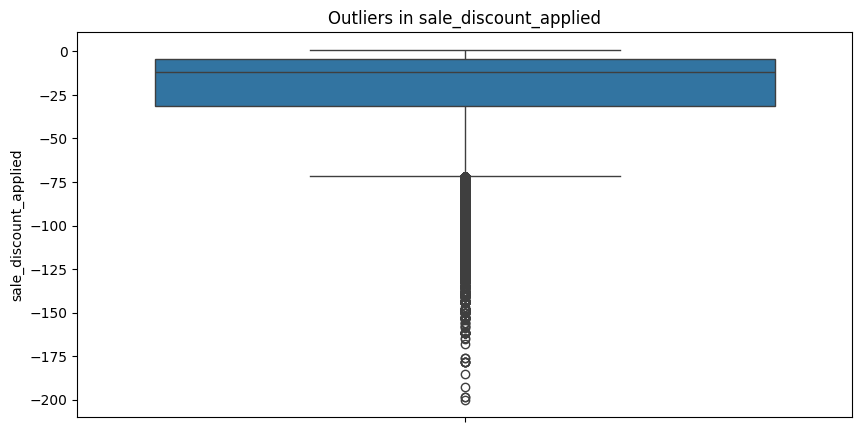

number of outliers: 12775 , percentage: 3.71


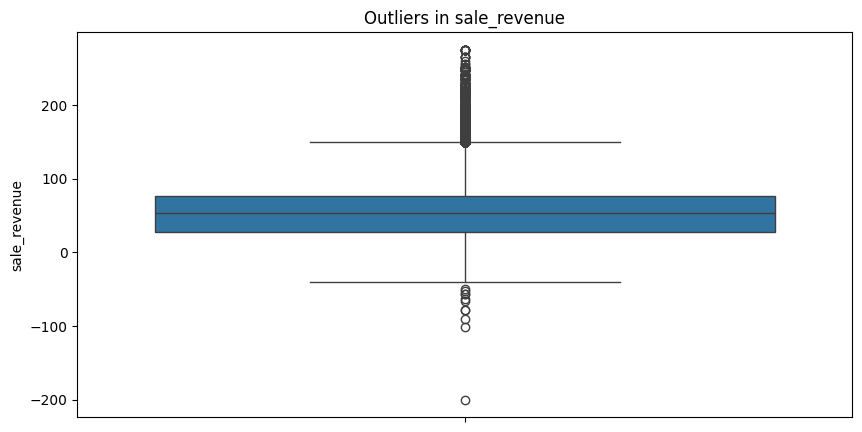

number of outliers: 5003 , percentage: 1.45


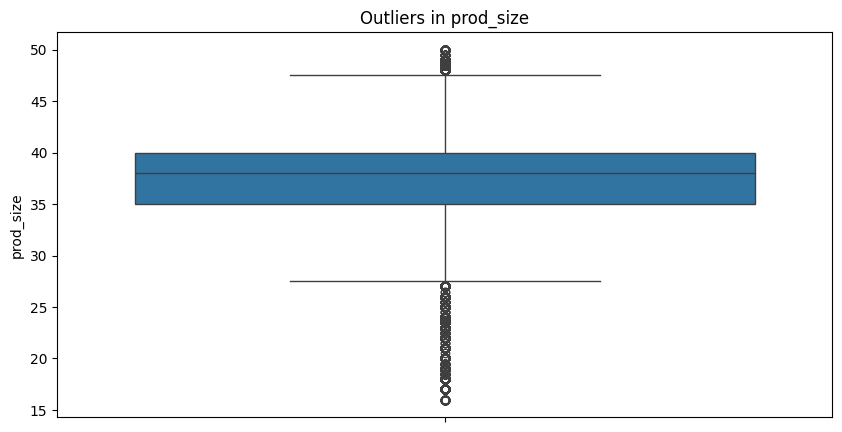

number of outliers: 36712 , percentage: 10.67


In [16]:
for column in ["sale_discount_applied", "sale_revenue", "prod_size"]:

    transactions[column]= pd.to_numeric(transactions[column],errors='coerce')
    transactions[column].dropna()
    
    plt.figure(figsize=(10, 5))
    sns.boxplot(y=transactions[column])
    plt.title(f'Outliers in {column}')
    plt.show()


    Q1=transactions[column].quantile(0.25)
    Q3=transactions[column].quantile(0.75)
    IQR= Q3-Q1
    count= ((transactions[column]<Q1-1.5*IQR) | (transactions[column]>Q3+1.5*IQR)).sum()
    percentage= round(count/len(transactions) *100 ,2)
    print("number of outliers:",count, ", percentage:", percentage)

In [17]:
transactions['prod_size_bin'] = pd.cut(transactions['prod_size'], bins=[0, 35, 44, 100], labels=[1, 2, 3]) #1=kids, 2=standard, 3=big size
print(transactions['prod_size_bin'].value_counts())

prod_size_bin
2    242602
1     87186
3     14423
Name: count, dtype: int64


In [18]:
print((transactions["sale_revenue"]<0).sum())
print((transactions[transactions["sale_revenue"]<0]).head())

2726
              cust_id  order_date   pack_date           sale_id  \
160  drfh2oherb7najov  2016-01-01  2016-01-04  il53x7ywpcfjshtl   
222  6wkol4xmhbjwyqpk  2016-01-01  2016-01-05  yfuvxqckd3kdfqoj   
223  zsch7wkpbwgtjktd  2016-01-01  2016-01-04  4jdj25dp43g5bizd   
293  6o7ycr4ybvsxoy77  2016-01-02  2016-01-04  mlcqkvk4tpfwfpiz   
355  pfw3tsdwgbwtd723  2016-01-02  2016-01-04  dx2r47hus35zovfv   

     sale_discount_applied  sale_revenue returned_to_shop_id  \
160                 -40.98         -5.00          wgvwpxz354   
222                 -33.00         -1.50          m4u2pedciy   
223                 -30.76         -5.88          tda6fq6yzi   
293                 -19.07         -3.08          ncfk3d5hru   
355                 -25.38         -1.40          wqnkwa54pu   

              prod_id  prod_size  prod_web_only prod_season prod_brand  \
160  keljrif27g6dkumn       41.0              1         W15     Replay   
222  xm4nita6sd6timfy       26.0              0         W15

In [19]:
transactions['discount_quantile'] = pd.qcut(transactions['sale_discount_applied'], q=5, labels=['Q1 (0-20%)', 'Q2 (20-40%)', 'Q3 (40-60%)', 'Q4 (60-80%)', 'Q5 (80-100%)'])
## Q1 = small discount, Q5= huge discount

transactions['revenue_quantile'] = pd.qcut(transactions['sale_revenue'], q=5,labels=['Q1 (0-20%)', 'Q2 (20-40%)', 'Q3 (40-60%)', 'Q4 (60-80%)', 'Q5 (80-100%)'])
## Q1 = small revenue, Q5= huge revenue


In [ ]:
print(transactions.head())
print(train.head())

,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,prod_season,prod_brand,prod_title,prod_color,prod_type_1,prod_type_3,prod_type_5,prod_material,prod_outlet,prod_size_bin,discount_quantile,revenue_quantile
0,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-35.70,83.30,NaN,543rj4mzzjnzkbil,30.0,0,W14,STONES and BONES,Bruine Velcrobottine STONES and BONES,dark brown,boys,high shoes,boots (velcro),leather,0,1,Q2 (20-40%),Q5 (80-100%)
1,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-39.98,0.00,ztodvuuaje,7ewnqhtrquent4cy,44.0,0,W15,Mario Rossi,Mario Rossi Cognac Boot,cognac,men,high shoes,dress boots,leather,0,2,Q1 (0-20%),Q1 (0-20%)
2,a63atwr2ig2jfprr,2016-01-01,2016-01-04,p4y4726y24dcxawf,-24.00,0.00,5tiaacoboa,cwtye5jwqr43a56i,38.5,0,W15,Gabor,Gabor Blauwe Veterschoen met Dierenprint,blue,women,sneakers,lace-up shoes,suede,0,2,Q2 (20-40%),Q1 (0-20%)
3,zr7ihbfbi6gcy2tz,2016-01-01,2016-01-05,3etkl2xv6pxku4kt,-26.23,43.72,NaN,mqw2seipp2wtylnw,35.0,0,W15,Geox,Geox Blauwe Velcroschoen,dark blue,boys,low shoes,velcro shoes,synthetic leather,0,1,Q2 (20-40%),Q3 (40-60%)
4,dt7cthjqnjmkbiu6,2016-01-01,2016-01-05,lneitdgyfvrie3jo,-29.98,0.00,geja5b25na,5ut47kvr6zlx6y62,25.0,0,W15,STONES and BONES,STONES and BONES Taupe Velcroboots,taupe,boys,high shoes,boots (velcro),NaN,0,1,Q2 (20-40%),Q1 (0-20%)


In [26]:
#Marte 
## Additional Data Cleaning steps for feature engineering
### Main Material
transactions["prod_material"].value_counts() # a lot of options in same field > make a new material variable with only the first category 
transactions["material_main"] = transactions["prod_material"].str.split(",").str[0].str.strip()
print(transactions["material_main"].value_counts()) 


### Type_3
transactions["prod_type_3"].value_counts() # a lot of categories, only take the first category 
transactions["prod_type_3_main"] = transactions["prod_type_3"].str.split(",").str[0].str.strip()
print(transactions["prod_type_3_main"].value_counts())


### Season
transactions["prod_season"].value_counts() # a lot of categories > make new variabels ( (1) seasons: winter, summer, NOS > never out of stock and CONS > basics; (2) years and (3) type of collection)

# extract season code 
transactions["season_code"] = transactions["prod_season"].str.extract(r'^([A-Z]+)')

# extract year (last 2 digits if present) and convert to full year
transactions["season_year"] = transactions["prod_season"].str.extract(r'(\d{2})$')
transactions["season_year"] = transactions["season_year"].astype(float) + 2000

# mapping to season names
season_map = {
    "Z": "Summer",
    "W": "Winter",
    "MZ": "Mid-season Summer",
    "MW": "Mid-season Winter",
    "SZ": "Special Summer",
    "SW": "Special Winter",
    "NOS": "Never Out of Stock",
    "CONS": "Consignment"
}

transactions["season"] = transactions["season_code"].map(season_map)

# mapping to type (main season, mid-season, ... )
type_map = {
    "Z": "Main",
    "W": "Main",
    "MZ": "Mid-season",
    "MW": "Mid-season",
    "SZ": "Special",
    "SW": "Special",
    "NOS": "NOS",
    "CONS": "CONS"
}

transactions["season_type"] = transactions["season_code"].map(type_map)

material_main
leather              143960
textile               60931
synthetic leather     49481
suede                 32449
nubuck                14165
patent leather         9353
synthetic              7016
rubber                 2104
wool                   1088
velour                  477
synthetic wool          447
Name: count, dtype: int64
prod_type_3_main
sneakers        76005
low shoes       51295
sandals         46108
high shoes      33773
ankle boots     31803
pumps           29334
boots           21389
flip-flops      18898
slippers        15173
ballet flats    10172
dress shoes      6902
snow boots       1730
baby shoes        926
sports shoes      692
hiking shoes       12
Name: count, dtype: int64


In [27]:
transactions.head()

,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,prod_season,prod_brand,prod_title,prod_color,prod_type_1,prod_type_3,prod_type_5,prod_material,prod_outlet,prod_size_bin,discount_quantile,revenue_quantile,material_main,prod_type_3_main,season_code,season_year,season,season_type
0,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-35.70,83.30,NaN,543rj4mzzjnzkbil,30.0,0,W14,STONES and BONES,Bruine Velcrobottine STONES and BONES,dark brown,boys,high shoes,boots (velcro),leather,0,1,Q2 (20-40%),Q5 (80-100%),leather,high shoes,W,2014.0,Winter,Main
1,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-39.98,0.00,ztodvuuaje,7ewnqhtrquent4cy,44.0,0,W15,Mario Rossi,Mario Rossi Cognac Boot,cognac,men,high shoes,dress boots,leather,0,2,Q1 (0-20%),Q1 (0-20%),leather,high shoes,W,2015.0,Winter,Main
2,a63atwr2ig2jfprr,2016-01-01,2016-01-04,p4y4726y24dcxawf,-24.00,0.00,5tiaacoboa,cwtye5jwqr43a56i,38.5,0,W15,Gabor,Gabor Blauwe Veterschoen met Dierenprint,blue,women,sneakers,lace-up shoes,suede,0,2,Q2 (20-40%),Q1 (0-20%),suede,sneakers,W,2015.0,Winter,Main
3,zr7ihbfbi6gcy2tz,2016-01-01,2016-01-05,3etkl2xv6pxku4kt,-26.23,43.72,NaN,mqw2seipp2wtylnw,35.0,0,W15,Geox,Geox Blauwe Velcroschoen,dark blue,boys,low shoes,velcro shoes,synthetic leather,0,1,Q2 (20-40%),Q3 (40-60%),synthetic leather,low shoes,W,2015.0,Winter,Main
4,dt7cthjqnjmkbiu6,2016-01-01,2016-01-05,lneitdgyfvrie3jo,-29.98,0.00,geja5b25na,5ut47kvr6zlx6y62,25.0,0,W15,STONES and BONES,STONES and BONES Taupe Velcroboots,taupe,boys,high shoes,boots (velcro),NaN,0,1,Q2 (20-40%),Q1 (0-20%),NaN,high shoes,W,2015.0,Winter,Main


# 5. Construction Train Data Set

In [28]:
#DORIAN
## Construction of the train dataset before splitting it.
df = transactions.merge(train, on="cust_id", how="inner")

print(df.shape)
df.head()

(275166, 29)


,cust_id,order_date,pack_date,sale_id,sale_discount_applied,sale_revenue,returned_to_shop_id,prod_id,prod_size,prod_web_only,prod_season,prod_brand,prod_title,prod_color,prod_type_1,prod_type_3,prod_type_5,prod_material,prod_outlet,prod_size_bin,discount_quantile,revenue_quantile,material_main,prod_type_3_main,season_code,season_year,season,season_type,revenue_2018_2019
0,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-35.70,83.30,NaN,543rj4mzzjnzkbil,30.0,0,W14,STONES and BONES,Bruine Velcrobottine STONES and BONES,dark brown,boys,high shoes,boots (velcro),leather,0,1,Q2 (20-40%),Q5 (80-100%),leather,high shoes,W,2014.0,Winter,Main,209.85
1,klantwj2374mzmab,2016-01-01,2016-01-04,wa46phiwo6neterg,-39.98,0.00,ztodvuuaje,7ewnqhtrquent4cy,44.0,0,W15,Mario Rossi,Mario Rossi Cognac Boot,cognac,men,high shoes,dress boots,leather,0,2,Q1 (0-20%),Q1 (0-20%),leather,high shoes,W,2015.0,Winter,Main,209.85
2,a63atwr2ig2jfprr,2016-01-01,2016-01-04,p4y4726y24dcxawf,-24.00,0.00,5tiaacoboa,cwtye5jwqr43a56i,38.5,0,W15,Gabor,Gabor Blauwe Veterschoen met Dierenprint,blue,women,sneakers,lace-up shoes,suede,0,2,Q2 (20-40%),Q1 (0-20%),suede,sneakers,W,2015.0,Winter,Main,82.93
3,zr7ihbfbi6gcy2tz,2016-01-01,2016-01-05,3etkl2xv6pxku4kt,-26.23,43.72,NaN,mqw2seipp2wtylnw,35.0,0,W15,Geox,Geox Blauwe Velcroschoen,dark blue,boys,low shoes,velcro shoes,synthetic leather,0,1,Q2 (20-40%),Q3 (40-60%),synthetic leather,low shoes,W,2015.0,Winter,Main,89.95
4,dt7cthjqnjmkbiu6,2016-01-01,2016-01-05,lneitdgyfvrie3jo,-29.98,0.00,geja5b25na,5ut47kvr6zlx6y62,25.0,0,W15,STONES and BONES,STONES and BONES Taupe Velcroboots,taupe,boys,high shoes,boots (velcro),NaN,0,1,Q2 (20-40%),Q1 (0-20%),NaN,high shoes,W,2015.0,Winter,Main,0.00


In [29]:
customers = train["cust_id"]
y_binary = (train["revenue_2018_2019"] > 0).astype(int)

cust_cal, cust_val = train_test_split(
    customers,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)
X_cal = df[df["cust_id"].isin(cust_cal)]
X_val = df[df["cust_id"].isin(cust_val)]

Splitting on customer ID > advantages: no data leakages as the model doesn't see the same customer in the train and test data, good for new-customer prediction (and easy stratification), a little bit more difficult to predict future sales of the same customer (do not know if that's needed)

In [30]:
#Quick sanitity ceck
set(X_cal["cust_id"]).intersection(set(X_val["cust_id"]))
print("Original zero rate:", (train["revenue_2018_2019"] == 0).mean())

print(
    "Calibration zero rate:",
    X_cal.groupby("cust_id")["revenue_2018_2019"].first().eq(0).mean()
)

print(
    "Validation zero rate:",
    X_val.groupby("cust_id")["revenue_2018_2019"].first().eq(0).mean()
)

Original zero rate: 0.6341227024384386
Calibration zero rate: 0.6341238528175658
Validation zero rate: 0.6341181011192589


In [31]:
X_cal.to_csv("data/calibration_transactions.csv", index=False)
X_val.to_csv("data/validation_transactions.csv", index=False)
#Run this to create those dataset and instead of just having them in your kernel.